### Forest Fire Risk And Prediction Model
#### By : Shivam Singh


In [16]:
# Librarys

# Import manipulation librarys
import numpy as np
import pandas as pd

# Import visualization librarys
import matplotlib.pyplot as plt
import seaborn as sns

# Import warnings
import warnings
warnings.filterwarnings('ignore')

# Orderdict
from collections import  OrderedDict

In [17]:
# Data Ingestion 
df = pd.read_csv(r'C:\15Days15Project\Forest-Fire-Risk-and-Impact-Prediction-Model\data\raw\forestfires.csv')
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [18]:
df["Fire"] = df["area"].apply(lambda x: 1 if x > 0 else 0)

In [19]:
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,Fire
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0,0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0,0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0,0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0,0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0,0


In [20]:
df.drop(columns= 'area' ,inplace= True)

<Axes: xlabel='Fire', ylabel='count'>

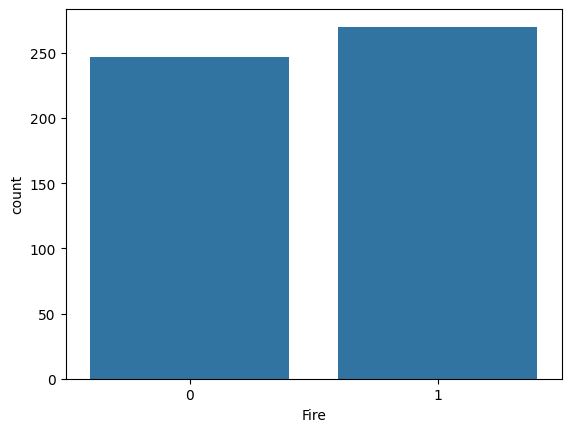

In [21]:
sns.countplot(data = df , x = 'Fire')

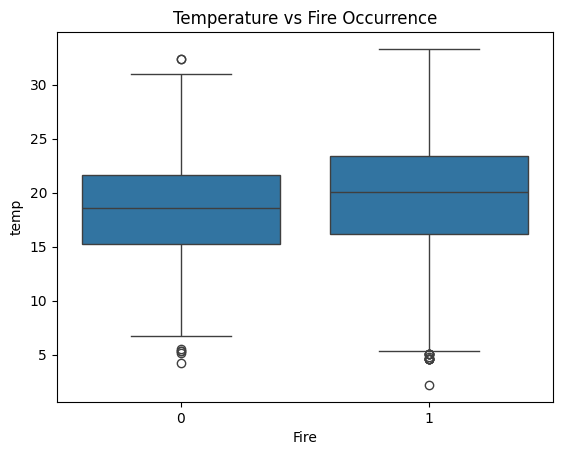

In [22]:
sns.boxplot(x="Fire", y="temp", data=df)
plt.title("Temperature vs Fire Occurrence")
plt.show()

<Axes: >

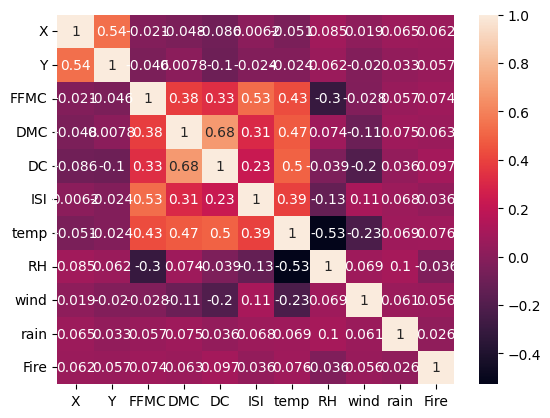

In [ ]:
sns.heatmap(df.corr(numeric_only= True) , annot= True)

In [23]:
# Descriptive stats

def descriptive_stats():
    numerical_col = df.select_dtypes(exclude = 'object').columns
    categorica_col = df.select_dtypes(include = 'object').columns
    num_stats = []
    cat_stats = []
    data_info = []

    for i in numerical_col:
        Q1 = df[i].quantile(0.25)
        Q3 = df[i].quantile(0.75)
        IQR = Q3 - Q1 
        LF = Q1 - 1.5*IQR
        UF = Q3 + 1.5*IQR

        outlier_count = len(df[(df[i] < LF) | (df[i] > UF)])
        outlier_percentage = outlier_count / len(df[i]) * 100

        numerical_stats = OrderedDict({
            "Feature " : i ,
            "Q1" : Q1,
            "Q3" : Q3,
            "IQR" : IQR,
            "LF" : LF,
            "UF" : UF,
            "Mean" : df[i].mean(),
            "Median" : df[i].median(),
            "Min" : df[i].min(),
            "Max" : df[i].max(),
            "Outlier count" : outlier_count,
            "outlier percentage" : outlier_percentage,
            "standard derivation": df[i].std(),
            "variance" : df[i].var(),
            "skewness" : df[i].skew(),
            "kurtosis" : df[i].kurtosis()
        })
        num_stats.append(numerical_stats)
    numerical_stats_report = pd.DataFrame(num_stats)
    for i in categorica_col:
        categorical_stats = OrderedDict({
            "Feature" : i , 
            "Unquie count" : df[i].nunique(),
            "Value count" : df[i].value_counts(),
            "mode" : df[i].mode()
        })
        cat_stats.append(categorical_stats)
    categorical_stats_report = pd.DataFrame(cat_stats)


    for i in df.columns : 
        data1 = OrderedDict({
            "Feature" : i ,
            "Missing value" : df[i].isnull().sum(),
            "Unqiue value" : df[i].nunique(),
            "value count " : df[i].value_counts().to_dict()
        })
        data_info.append(data1)
    data_info_report = pd.DataFrame(data_info)

    return categorical_stats_report,numerical_stats_report,data_info_report

categorical_stats_report,numerical_stats_report,data_info_report = descriptive_stats()

In [25]:
# Numerical stats
numerical_stats_report


,Feature,Q1,Q3,IQR,LF,UF,Mean,Median,Min,Max,Outlier count,outlier percentage,standard derivation,variance,skewness,kurtosis
0,X,3.0,7.0,4.0,-3.00,13.00,4.669246,4.0,1.0,9.0,0,0.000000,2.313778,5.353568,0.036246,-1.172331
1,Y,4.0,5.0,1.0,2.50,6.50,4.299807,4.0,2.0,9.0,51,9.864603,1.229900,1.512655,0.417296,1.420553
2,FFMC,90.2,92.9,2.7,86.15,96.95,90.644681,91.6,18.7,96.2,53,10.251451,5.520111,30.471624,-6.575606,67.066041
3,DMC,68.6,142.4,73.8,-42.10,253.10,110.872340,108.3,1.1,291.3,17,3.288201,64.046482,4101.951889,0.547498,0.204822
4,DC,437.7,713.9,276.2,23.40,1128.20,547.940039,664.2,7.9,860.6,8,1.547389,248.066192,61536.835467,-1.100445,-0.245244
5,ISI,6.5,10.8,4.3,0.05,17.25,9.021663,8.4,0.0,56.1,23,4.448743,4.559477,20.788832,2.536325,21.458037
6,temp,15.5,22.8,7.3,4.55,33.75,18.889168,19.3,2.2,33.3,2,0.386847,5.806625,33.716898,-0.331172,0.136166
7,RH,33.0,53.0,20.0,3.00,83.00,44.288201,42.0,15.0,100.0,12,2.321083,16.317469,266.259802,0.862904,0.438183
8,wind,2.7,4.9,2.2,-0.60,8.20,4.017602,4.0,0.4,9.4,13,2.514507,1.791653,3.210019,0.571001,0.054324
9,rain,0.0,0.0,0.0,0.00,0.00,0.021663,0.0,0.0,6.4,8,1.547389,0.295959,0.087592,19.816344,421.295964


In [26]:
# Categorical stats
categorical_stats_report

,Feature,Unquie count,Value count,mode
0,month,12,month aug 184 sep 172 mar 54 jul ...,"0 aug Name: month, dtype: object"
1,day,7,day sun 95 fri 85 sat 84 mon 74 tu...,"0 sun Name: day, dtype: object"


In [27]:
# Data Info 
data_info_report

,Feature,Missing value,Unqiue value,value count
0,X,0,9,"{4: 91, 6: 86, 2: 73, 8: 61, 7: 60, 3: 55, 1: ..."
1,Y,0,7,"{4: 203, 5: 125, 6: 74, 3: 64, 2: 44, 9: 6, 8: 1}"
2,month,0,12,"{'aug': 184, 'sep': 172, 'mar': 54, 'jul': 32,..."
3,day,0,7,"{'sun': 95, 'fri': 85, 'sat': 84, 'mon': 74, '..."
4,FFMC,0,106,"{92.1: 28, 91.6: 28, 91.0: 22, 91.7: 19, 93.7:..."
5,DMC,0,215,"{99.0: 10, 129.5: 9, 142.4: 8, 231.1: 8, 137.0..."
6,DC,0,219,"{745.3: 10, 692.6: 9, 698.6: 8, 692.3: 8, 601...."
7,ISI,0,119,"{9.6: 23, 7.1: 21, 6.3: 20, 7.0: 17, 8.4: 17, ..."
8,temp,0,192,"{19.6: 8, 17.4: 8, 15.4: 7, 20.6: 7, 19.1: 6, ..."
9,RH,0,75,"{27: 33, 39: 24, 35: 20, 42: 17, 43: 17, 45: 1..."


In [29]:
# Preprocessing Data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,RobustScaler 

X = df.drop(columns='Fire' )
y = df['Fire']

X_train,X_test,y_train,y_test = train_test_split( X ,y , 
                                                 test_size= 0.30 ,
                                                 random_state= 7 )

le = LabelEncoder()
for i in X_train.select_dtypes(include= 'object').columns:
    X_train[i] = le.fit_transform(X_train[i])
    X_test[i] = le.transform(X_test[i])

 # step 4 : Scaling Technique : RobustScaler()
sc = RobustScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [30]:
# Model Training
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


def model_building(X_train, X_test, y_train, y_test):

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'Support Vector Machine': SVC()
    }

    model_performance = []

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        report = OrderedDict({
            'Model_Name': model_name,
            'Accuracy_Score': accuracy_score(y_test, y_pred),
            'Confusion_Matrix': confusion_matrix(y_test, y_pred),
            'Classification_Report': classification_report(y_test, y_pred, output_dict=True)
        })

        model_performance.append(report)

    return pd.DataFrame(model_performance)

In [34]:
model_report = model_building(X_train, X_test, y_train, y_test)
model_report

,Model_Name,Accuracy_Score,Confusion_Matrix,Classification_Report
0,Logistic Regression,0.532051,"[[27, 45], [28, 56]]","{'0': {'precision': 0.4909090909090909, 'recal..."
1,Decision Tree,0.551282,"[[36, 36], [34, 50]]","{'0': {'precision': 0.5142857142857142, 'recal..."
2,Random Forest,0.564103,"[[35, 37], [31, 53]]","{'0': {'precision': 0.5303030303030303, 'recal..."
3,AdaBoost,0.628205,"[[33, 39], [19, 65]]","{'0': {'precision': 0.6346153846153846, 'recal..."
4,Gradient Boosting,0.576923,"[[35, 37], [29, 55]]","{'0': {'precision': 0.546875, 'recall': 0.4861..."
5,Support Vector Machine,0.583333,"[[24, 48], [17, 67]]","{'0': {'precision': 0.5853658536585366, 'recal..."


#### Final :
Multiple classification models were evaluated, including Logistic Regression, Decision Trees, Random Forest, Gradient Boosting, Support Vector Machines, and AdaBoost. Among them, AdaBoost achieved the best overall performance with the highest accuracy and improved recall for fire events. Given the importance of minimizing missed fire detections, AdaBoost was selected as the final classification model.